# Held-out shopping LoRA analysis

This notebook compares LoRA overseer runs against the closest full-shopping baseline sessions on the shopping held-out split. Baseline sessions are filtered to `configs/shopping/splits.yaml` `hold_out`; LoRA sessions are loaded from their `shopping=lora` held-out runs and validated against the same case set.


In [1]:
# Top-level configuration. Run this notebook from the repository root with Pixi.
from __future__ import annotations

import json
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pixi.toml").exists() and (candidate / "notebooks" / "analysis_lib.py").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing pixi.toml and notebooks/analysis_lib.py")


ROOT = find_repo_root(Path.cwd().resolve())
for import_path in (ROOT, ROOT / "notebooks"):
    import_path_s = str(import_path)
    if import_path_s not in sys.path:
        sys.path.insert(0, import_path_s)

import analysis_lib as al  # noqa: E402

EXPERIMENTS_ROOT = ROOT / "outputs" / "deepplanning" / "experiments"
SPLIT_CONFIG = ROOT / "configs" / "shopping" / "splits.yaml"
TRACE_TOKEN_DIR = ROOT / "outputs" / "deepplanning" / "langfuse_trace_tokens"
HELD_OUT_TOKEN_SUMMARY_CSV = TRACE_TOKEN_DIR / "held_out_token_summary.csv"
EXPORT_CSV = False
EXPORT_DIR = ROOT / "outputs" / "deepplanning" / "held_out_lora_analysis"

EXPECTED_SYSTEMS = [
    "C2",
    "C2-nt",
    "C2-deepseek",
    "C2-deepseek-nt",
    "C2-lora",
    "C2-deepseek-lora",
]

SYSTEM_SPECS = {
    "C2": {
        "experiment_dir": "shopping-c2",
        "contract_source": "DS-V4-Flash thinking",
        "action_review_source": "DS-V4-Flash thinking",
    },
    "C2-nt": {
        "experiment_dir": "shopping-c2-nt",
        "contract_source": "DS-V4-Flash thinking-off",
        "action_review_source": "DS-V4-Flash thinking-off",
    },
    "C2-deepseek": {
        "experiment_dir": "shopping-c2-deepseek",
        "contract_source": "DS-V4-Flash thinking",
        "action_review_source": "DS-V4-Flash thinking",
    },
    "C2-deepseek-nt": {
        "experiment_dir": "shopping-c2-deepseek-nt",
        "contract_source": "DS-V4-Flash thinking-off",
        "action_review_source": "DS-V4-Flash thinking-off",
    },
    "C2-lora": {
        "experiment_dir": "shopping-c2-lora",
        "contract_source": "DS-V4-Flash thinking (reused)",
        "action_review_source": "LoRA",
    },
    "C2-deepseek-lora": {
        "experiment_dir": "shopping-c2-deepseek-lora",
        "contract_source": "DS-V4-Flash thinking (reused)",
        "action_review_source": "LoRA",
    },
}

LORA_SYSTEMS = {"C2-lora", "C2-deepseek-lora"}
PAIRWISE_COMPARISONS = [
    ("C2-lora", "C2", "LoRA vs closest C2 baseline"),
    ("C2-lora", "C2-nt", "LoRA vs C2 thinking-off baseline"),
    ("C2-deepseek-lora", "C2-deepseek", "LoRA vs closest DeepSeek-executor baseline"),
    ("C2-deepseek-lora", "C2-deepseek-nt", "LoRA vs DeepSeek-executor thinking-off baseline"),
    ("C2", "C2-nt", "thinking vs thinking-off baseline context"),
    ("C2-deepseek", "C2-deepseek-nt", "thinking vs thinking-off DeepSeek-executor context"),
]

al.SYSTEM_ORDER = EXPECTED_SYSTEMS.copy()
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 4)

print(f"Repo root: {ROOT}")


Repo root: /Users/dntgafck/msai/thesis/deepplanning-selective-oversight


## Load and validate held-out rows

The selection is intentionally exact: only the six scoped experiment directories are loaded, and the typo directory `shopping-c2-deepseek-lor` is never globbed in.


In [2]:
def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def read_holdout_split(path: Path) -> dict[int, set[str]]:
    try:
        import yaml

        payload = yaml.safe_load(path.read_text(encoding="utf-8"))
        raw = payload["hold_out"]
    except ImportError:
        raw = {}
        for line in path.read_text(encoding="utf-8").splitlines():
            match = re.match(r"\s*level_(\d+):\s*\[(.*)\]\s*$", line)
            if match:
                raw[f"level_{match.group(1)}"] = [item.strip().strip('"\'') for item in match.group(2).split(",")]

    split = {}
    for key, values in raw.items():
        level = int(str(key).removeprefix("level_"))
        split[level] = {f"case_{value}" for value in values}
    if set(split) != {1, 2, 3}:
        raise AssertionError(f"Expected hold_out levels 1, 2, and 3; found {sorted(split)}")
    return split


def exact_session_roots(experiment_dir_name: str) -> list[Path]:
    if experiment_dir_name == "shopping-c2-deepseek-lor":
        raise AssertionError("Typo experiment directory is out of scope")
    experiment_dir = EXPERIMENTS_ROOT / experiment_dir_name
    roots = sorted(path for path in experiment_dir.iterdir() if (path / "experiment_session.json").exists())
    if not roots:
        raise FileNotFoundError(f"No timestamped sessions found under {experiment_dir}")
    return roots


def filter_to_holdout(per_case_raw: pd.DataFrame, holdout_cases: dict[int, set[str]]) -> pd.DataFrame:
    frame = per_case_raw.copy()
    frame["case_name"] = frame["case_name"].astype(str)
    mask = frame.apply(lambda row: row["case_name"] in holdout_cases[int(row["level"])], axis=1)
    return frame.loc[mask].copy().reset_index(drop=True)


def validate_system_selection(per_case_raw: pd.DataFrame) -> None:
    observed = set(per_case_raw["system"].unique())
    expected = set(EXPECTED_SYSTEMS)
    if observed != expected:
        raise AssertionError(f"Expected exactly {sorted(expected)}, found {sorted(observed)}")
    forbidden = {"A", "B", "D", "C2-noretry", "C2-deepseek-pro", "shopping-c2-deepseek-lor"}
    overlap = observed.intersection(forbidden)
    if overlap:
        raise AssertionError(f"Forbidden systems included: {sorted(overlap)}")


def validate_heldout_shape(per_case: pd.DataFrame, holdout_cases: dict[int, set[str]]) -> None:
    problems = []
    for system in EXPECTED_SYSTEMS:
        runs = sorted(per_case.loc[per_case["system"] == system, "run"].unique())
        if not runs:
            problems.append(f"{system}: no runs after held-out filtering")
            continue
        for run in runs:
            run_rows = per_case[(per_case["system"] == system) & (per_case["run"] == run)]
            for level, expected_cases in holdout_cases.items():
                level_rows = run_rows[run_rows["level"] == level]
                observed_cases = set(level_rows["case_name"])
                if observed_cases != expected_cases or len(level_rows) != len(expected_cases):
                    missing = sorted(expected_cases - observed_cases)
                    extra = sorted(observed_cases - expected_cases)
                    problems.append(
                        f"{system} run {run} level {level}: rows={len(level_rows)}, "
                        f"expected={len(expected_cases)}, missing={missing}, extra={extra}"
                    )
    if problems:
        raise AssertionError("Held-out shape validation failed:\n" + "\n".join(problems))


HOLDOUT_CASES = read_holdout_split(SPLIT_CONFIG)
session_roots_by_system = {
    system: exact_session_roots(spec["experiment_dir"])
    for system, spec in SYSTEM_SPECS.items()
}
session_roots = [root for system in EXPECTED_SYSTEMS for root in session_roots_by_system[system]]

per_case_raw = al.load_per_case(session_roots)
validate_system_selection(per_case_raw)
per_case = filter_to_holdout(per_case_raw, HOLDOUT_CASES)
validate_heldout_shape(per_case, HOLDOUT_CASES)

raw_counts = per_case_raw.groupby("system").size().rename("raw_rows")
heldout_counts = per_case.groupby("system").size().rename("heldout_rows")
filter_report = pd.concat([raw_counts, heldout_counts], axis=1).reindex(EXPECTED_SYSTEMS)
filter_report["dropped_rows"] = filter_report["raw_rows"] - filter_report["heldout_rows"]
filter_report["heldout_cases_per_run"] = (
    per_case.groupby("system")[["level", "case_name"]]
    .apply(lambda frame: frame.drop_duplicates().shape[0])
    .reindex(EXPECTED_SYSTEMS)
)

print(f"Loaded {len(session_roots)} selected sessions")
print(f"Held-out case IDs by level: { {level: sorted(cases) for level, cases in HOLDOUT_CASES.items()} }")
display(filter_report.reset_index(names="system"))


Loaded 7 selected sessions
Held-out case IDs by level: {1: ['case_10', 'case_15', 'case_24', 'case_3', 'case_30', 'case_32', 'case_34', 'case_8'], 2: ['case_13', 'case_2', 'case_21', 'case_26', 'case_28', 'case_29', 'case_42', 'case_46'], 3: ['case_10', 'case_13', 'case_20', 'case_4', 'case_5', 'case_7', 'case_8', 'case_9']}


,system,raw_rows,heldout_rows,dropped_rows,heldout_cases_per_run
0,C2,480,96,384,24
1,C2-nt,480,96,384,24
2,C2-deepseek,480,96,384,24
3,C2-deepseek-nt,480,96,384,24
4,C2-lora,96,96,0,24
5,C2-deepseek-lora,96,96,0,24


## Provenance


In [3]:
def metadata_value(metadata: dict, *keys: str):
    value = metadata
    for key in keys:
        if not isinstance(value, dict):
            return None
        value = value.get(key)
    return value


def provenance_table() -> pd.DataFrame:
    rows = []
    run_counts = per_case.groupby("system")["run"].nunique()
    heldout_case_counts = per_case.groupby("system")[["level", "case_name"]].apply(
        lambda frame: frame.drop_duplicates().shape[0]
    )
    for system in EXPECTED_SYSTEMS:
        roots = session_roots_by_system[system]
        metadata = [read_json(root / "experiment_session.json") for root in roots]
        executors = sorted({metadata_value(item, "parameters", "models", "executor") for item in metadata})
        overseers = sorted({metadata_value(item, "parameters", "models", "overseer") for item in metadata})
        shopping_splits = sorted({metadata_value(item, "parameters", "shopping", "split") for item in metadata})
        rows.append(
            {
                "system": system,
                "executor_model": ", ".join(executors),
                "overseer_or_action_review_model": ", ".join(overseers),
                "contract_source": SYSTEM_SPECS[system]["contract_source"],
                "action_review_source": SYSTEM_SPECS[system]["action_review_source"],
                "experiment_dir": SYSTEM_SPECS[system]["experiment_dir"],
                "session_timestamps": ", ".join(root.name for root in roots),
                "configured_shopping_split": ", ".join(shopping_splits),
                "run_count": int(run_counts.loc[system]),
                "held_out_case_count": int(heldout_case_counts.loc[system]),
            }
        )
    return pd.DataFrame(rows)


provenance = provenance_table()
display(provenance)


,system,executor_model,overseer_or_action_review_model,contract_source,action_review_source,experiment_dir,session_timestamps,configured_shopping_split,run_count,held_out_case_count
0,C2,qwen3.5-9b,deepseek-v4-flash,DS-V4-Flash thinking,DS-V4-Flash thinking,shopping-c2,2026-04-30_09-18-02,all,4,24
1,C2-nt,qwen3.5-9b,deepseek-v4-flash-nt,DS-V4-Flash thinking-off,DS-V4-Flash thinking-off,shopping-c2-nt,2026-04-30_13-35-38,all,4,24
2,C2-deepseek,deepseek-v4-flash,deepseek-v4-flash,DS-V4-Flash thinking,DS-V4-Flash thinking,shopping-c2-deepseek,"2026-05-01_18-54-47, 2026-05-10_18-11-57",all,4,24
3,C2-deepseek-nt,deepseek-v4-flash,deepseek-v4-flash-nt,DS-V4-Flash thinking-off,DS-V4-Flash thinking-off,shopping-c2-deepseek-nt,2026-05-10_18-08-50,all,4,24
4,C2-lora,qwen3.5-9b,qwen2.5-7b-overseer-lora,DS-V4-Flash thinking (reused),LoRA,shopping-c2-lora,2026-05-15_15-13-58,hold_out,4,24
5,C2-deepseek-lora,deepseek-v4-flash,qwen2.5-7b-overseer-lora,DS-V4-Flash thinking (reused),LoRA,shopping-c2-deepseek-lora,2026-05-15_14-56-51,hold_out,4,24


## Accuracy summary

All tables and plots below use the held-out-filtered `per_case` frame validated above.


In [4]:
summary = al.system_summary(per_case).set_index("system").reindex(EXPECTED_SYSTEMS).reset_index()
summary_display = summary.copy()
for column in ["case_acc_mean", "case_acc_std", "match_rate_mean", "L1_mean", "L2_mean", "L3_mean", "L1_std", "L2_std", "L3_std"]:
    if column in summary_display.columns:
        summary_display[column] = summary_display[column].map(lambda value: al.fmt_pct(value) if pd.notna(value) else "")
display(summary_display)

per_run = al.per_run_overall(per_case)
per_run = per_run.set_index("system").loc[EXPECTED_SYSTEMS].reset_index()
per_run_display = per_run.copy()
for column in ["case_accuracy", "mean_score", "match_rate"]:
    per_run_display[column] = per_run_display[column].map(al.fmt_pct)
display(per_run_display[["system", "run", "case_accuracy", "mean_score", "match_rate", "successes", "total"]])


,system,case_acc_mean,case_acc_std,match_rate_mean,runs,L1_mean,L2_mean,L3_mean,L1_std,L2_std,L3_std
0,C2,34.38%,3.99%,73.38%,4,50.00%,25.00%,28.12%,0.00%,10.21%,11.97%
1,C2-nt,32.29%,5.24%,68.98%,4,46.88%,25.00%,25.00%,6.25%,10.21%,10.21%
2,C2-deepseek,56.25%,4.17%,81.02%,4,65.62%,46.88%,56.25%,6.25%,11.97%,7.22%
3,C2-deepseek-nt,58.33%,10.21%,84.72%,4,71.88%,50.00%,53.12%,6.25%,14.43%,11.97%
4,C2-lora,36.46%,8.59%,76.16%,4,50.00%,21.88%,37.50%,0.00%,15.73%,17.68%
5,C2-deepseek-lora,47.92%,5.38%,81.02%,4,68.75%,21.88%,53.12%,7.22%,6.25%,6.25%


,system,run,case_accuracy,mean_score,match_rate,successes,total
0,C2,0,29.17%,62.85%,64.81%,7,24
1,C2,1,37.50%,74.17%,75.93%,9,24
2,C2,2,33.33%,74.79%,75.93%,8,24
3,C2,3,37.50%,76.88%,76.85%,9,24
4,C2-nt,0,25.00%,57.43%,57.41%,6,24
5,C2-nt,1,37.50%,73.82%,75.00%,9,24
6,C2-nt,2,33.33%,69.24%,69.44%,8,24
7,C2-nt,3,33.33%,72.78%,74.07%,8,24
8,C2-deepseek,0,50.00%,78.33%,76.85%,12,24
9,C2-deepseek,1,58.33%,84.58%,84.26%,14,24


## Level breakdown


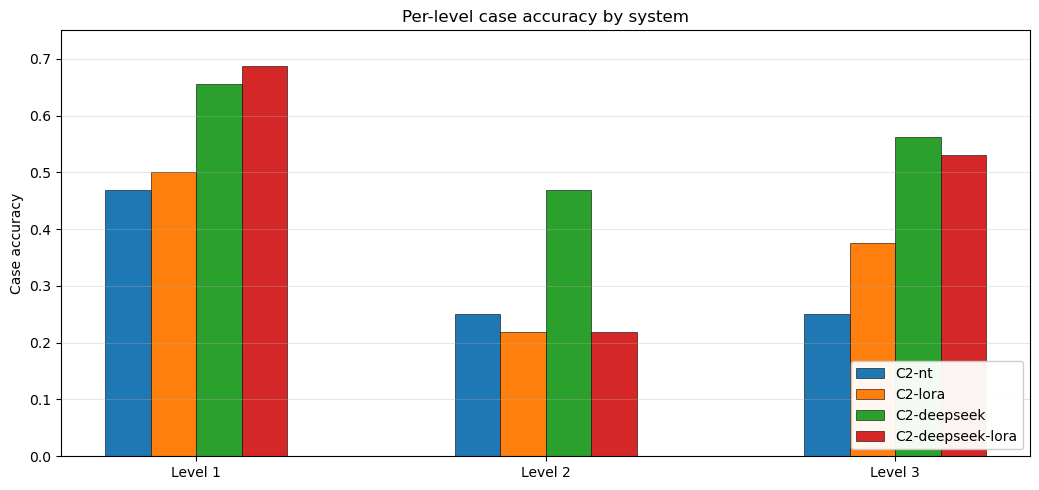

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10.5, 5))
per_level = al.per_run_per_level(per_case)
per_level = per_level[per_level['system'].isin(['C2-nt', 'C2-deepseek', 'C2-lora', 'C2-deepseek-lora'])]
agg_level = (per_level.groupby(['system','level'], as_index=False)
                       .agg(mean=('case_accuracy','mean'),
                            std=('case_accuracy','std')))

systems_present = [s for s in ['C2-nt', 'C2-lora', 'C2-deepseek', 'C2-deepseek-lora'] if s in agg_level.system.unique()]
levels = [1, 2, 3]
x = np.arange(len(levels))
width = 0.13
for i, s in enumerate(systems_present):
    sub = agg_level[agg_level.system == s].sort_values('level')
    means = sub['mean'].values
    stds  = sub['std'].fillna(0).values
    pos = x + (i - (len(systems_present)-1)/2) * width
    ax.bar(pos, means, width, label=s, capsize=3, edgecolor='black', linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels([f'Level {L}' for L in levels])
ax.set_ylabel('Case accuracy')
ax.set_title('Per-level case accuracy by system')
ax.legend(loc='lower right', framealpha=0.95)
ax.set_ylim(0, 0.75)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('out_per_level.png', bbox_inches='tight')
plt.show()


,system,level,case_acc_mean,case_acc_std,runs,cases
0,C2,1,50.00%,0.00%,4,8
1,C2,2,25.00%,10.21%,4,8
2,C2,3,28.12%,11.97%,4,8
3,C2-nt,1,46.88%,6.25%,4,8
4,C2-nt,2,25.00%,10.21%,4,8
5,C2-nt,3,25.00%,10.21%,4,8
6,C2-deepseek,1,65.62%,6.25%,4,8
7,C2-deepseek,2,46.88%,11.97%,4,8
8,C2-deepseek,3,56.25%,7.22%,4,8
9,C2-deepseek-nt,1,71.88%,6.25%,4,8


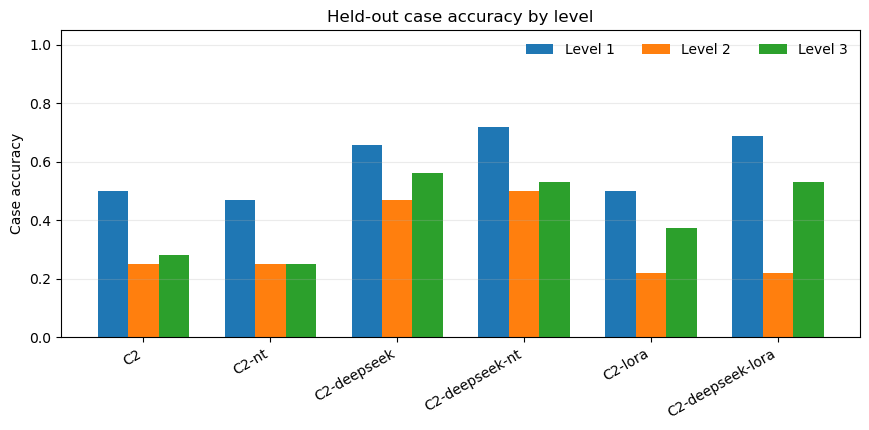

In [39]:
per_level = al.per_run_per_level(per_case)
level_summary = (
    per_level.groupby(["system", "level"], as_index=False)
    .agg(case_acc_mean=("case_accuracy", "mean"), case_acc_std=("case_accuracy", "std"), runs=("run", "nunique"), cases=("n", "first"))
)
level_summary["system"] = pd.Categorical(level_summary["system"], categories=EXPECTED_SYSTEMS, ordered=True)
level_summary = level_summary.sort_values(["system", "level"]).reset_index(drop=True)
level_display = level_summary.copy()
for column in ["case_acc_mean", "case_acc_std"]:
    level_display[column] = level_display[column].map(lambda value: al.fmt_pct(value) if pd.notna(value) else "")
display(level_display)

pivot = level_summary.pivot(index="system", columns="level", values="case_acc_mean").reindex(EXPECTED_SYSTEMS)
fig, ax = plt.subplots(figsize=(8.8, 4.4))
x = np.arange(len(EXPECTED_SYSTEMS))
width = 0.24
for offset, level in zip([-width, 0, width], [1, 2, 3]):
    ax.bar(x + offset, pivot[level].to_numpy(), width=width, label=f"Level {level}")
ax.set_xticks(x)
ax.set_xticklabels(EXPECTED_SYSTEMS, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Case accuracy")
ax.set_title("Held-out case accuracy by level")
ax.legend(ncols=3, frameon=False)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()


## Headline comparison


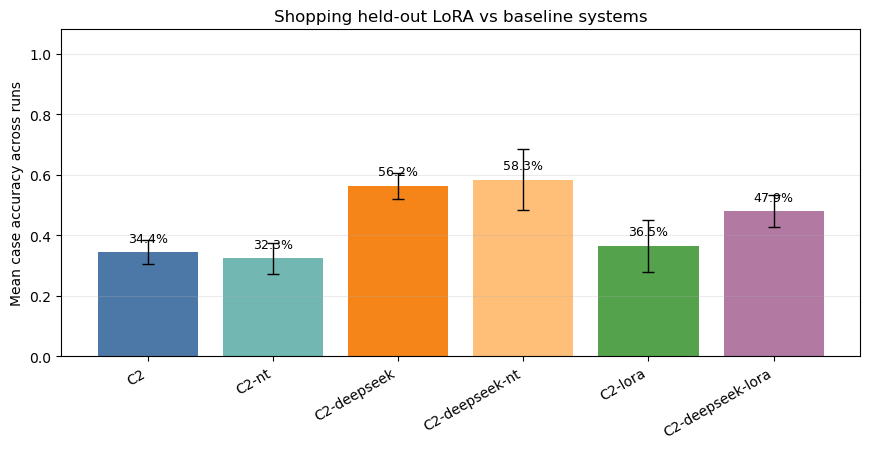

In [40]:
plot_df = summary.set_index("system").reindex(EXPECTED_SYSTEMS).reset_index()
colors = {
    "C2": "#4C78A8",
    "C2-nt": "#72B7B2",
    "C2-deepseek": "#F58518",
    "C2-deepseek-nt": "#FFBF79",
    "C2-lora": "#54A24B",
    "C2-deepseek-lora": "#B279A2",
}
fig, ax = plt.subplots(figsize=(8.8, 4.6))
bars = ax.bar(plot_df["system"], plot_df["case_acc_mean"], color=[colors[item] for item in plot_df["system"]])
ax.errorbar(
    plot_df["system"],
    plot_df["case_acc_mean"],
    yerr=plot_df["case_acc_std"].fillna(0),
    fmt="none",
    ecolor="black",
    capsize=4,
    linewidth=1,
)
for bar, value in zip(bars, plot_df["case_acc_mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, min(value + 0.025, 1.02), al.fmt_pct(value, nd=1), ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Mean case accuracy across runs")
ax.set_title("Shopping held-out LoRA vs baseline systems")
ax.set_xticks(np.arange(len(plot_df)))
ax.set_xticklabels(plot_df["system"], rotation=30, ha="right")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()


## Pairwise deltas


,comparison,lhs,rhs,lhs_case_acc,rhs_case_acc,delta_pp,lhs_case_wins,rhs_case_wins,ties,n_cases,mean_case_delta_pp
0,LoRA vs closest C2 baseline,C2-lora,C2,36.46%,34.38%,+2.08pp,6,4,14,24,+2.08pp
1,LoRA vs C2 thinking-off baseline,C2-lora,C2-nt,36.46%,32.29%,+4.17pp,5,2,17,24,+4.17pp
2,LoRA vs closest DeepSeek-executor baseline,C2-deepseek-lora,C2-deepseek,47.92%,56.25%,-8.33pp,2,10,12,24,-8.33pp
3,LoRA vs DeepSeek-executor thinking-off baseline,C2-deepseek-lora,C2-deepseek-nt,47.92%,58.33%,-10.42pp,1,9,14,24,-10.42pp
4,thinking vs thinking-off baseline context,C2,C2-nt,34.38%,32.29%,+2.08pp,4,2,18,24,+2.08pp
5,thinking vs thinking-off DeepSeek-executor context,C2-deepseek,C2-deepseek-nt,56.25%,58.33%,-2.08pp,4,5,15,24,-2.08pp


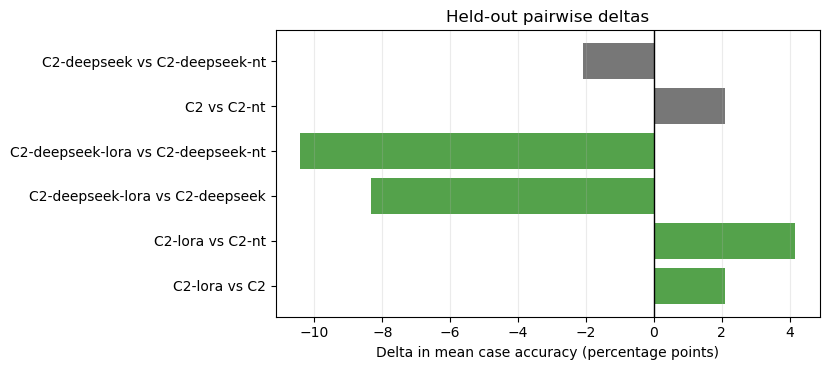

In [41]:
summary_index = summary.set_index("system")
pairwise_rows = []
for lhs, rhs, label in PAIRWISE_COMPARISONS:
    if lhs not in summary_index.index or rhs not in summary_index.index:
        continue
    joined = al.head_to_head(per_case, lhs, rhs)
    h2h = al.head_to_head_summary(joined, lhs, rhs)
    lhs_acc = summary_index.loc[lhs, "case_acc_mean"]
    rhs_acc = summary_index.loc[rhs, "case_acc_mean"]
    pairwise_rows.append(
        {
            "comparison": label,
            "lhs": lhs,
            "rhs": rhs,
            "lhs_case_acc": lhs_acc,
            "rhs_case_acc": rhs_acc,
            "delta_pp": 100 * (lhs_acc - rhs_acc),
            "lhs_case_wins": h2h[f"{lhs}_wins"],
            "rhs_case_wins": h2h[f"{rhs}_wins"],
            "ties": h2h["ties"],
            "n_cases": h2h["n_cases"],
            "mean_case_delta_pp": 100 * h2h["mean_delta"],
        }
    )

pairwise_deltas = pd.DataFrame(pairwise_rows)
pairwise_display = pairwise_deltas.copy()
for column in ["lhs_case_acc", "rhs_case_acc"]:
    pairwise_display[column] = pairwise_display[column].map(al.fmt_pct)
for column in ["delta_pp", "mean_case_delta_pp"]:
    pairwise_display[column] = pairwise_display[column].map(lambda value: f"{value:+.2f}pp")
display(pairwise_display)

fig, ax = plt.subplots(figsize=(8.4, 3.8))
y = np.arange(len(pairwise_deltas))
bar_colors = ["#54A24B" if "LoRA" in item else "#777777" for item in pairwise_deltas["comparison"]]
ax.barh(y, pairwise_deltas["delta_pp"], color=bar_colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(pairwise_deltas["lhs"] + " vs " + pairwise_deltas["rhs"])
ax.set_xlabel("Delta in mean case accuracy (percentage points)")
ax.set_title("Held-out pairwise deltas")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()


## DeepSeek level-2 per-case agreement

This table isolates the level-2 gap between `C2-deepseek-lora` and `C2-deepseek-nt`. The run-pattern columns show strict case-score outcomes across the four runs (`1` = solved, `0` = failed), so clustered failures are visible separately from run-to-run instability.


In [42]:
def per_case_run_pattern(frame: pd.DataFrame, system: str, level: int) -> pd.DataFrame:
    rows = frame[(frame["system"] == system) & (frame["level"] == level)].copy()
    pivot = rows.pivot_table(index="case_name", columns="run", values="case_score", aggfunc="mean")
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    out = pd.DataFrame(index=pivot.index)
    out[f"{system}_mean_case_score"] = pivot.mean(axis=1)
    out[f"{system}_failure_count"] = (pivot < 1.0).sum(axis=1).astype(int)
    out[f"{system}_run_pattern"] = pivot.apply(lambda row: "".join("1" if value == 1.0 else "0" for value in row), axis=1)
    return out.reset_index()


l2_lora = per_case_run_pattern(per_case, "C2-deepseek-lora", 2)
l2_baseline = per_case_run_pattern(per_case, "C2-deepseek-nt", 2)
l2_ds_agreement = l2_lora.merge(l2_baseline, on="case_name", how="inner")
l2_ds_agreement["delta_mean_case_score"] = (
    l2_ds_agreement["C2-deepseek-lora_mean_case_score"]
    - l2_ds_agreement["C2-deepseek-nt_mean_case_score"]
)
l2_ds_agreement = l2_ds_agreement.sort_values(
    ["C2-deepseek-lora_failure_count", "delta_mean_case_score", "case_name"],
    ascending=[False, True, True],
).reset_index(drop=True)
display(l2_ds_agreement)

lora_failures = l2_ds_agreement["C2-deepseek-lora_failure_count"]
always_failed = int((lora_failures == per_case[per_case["system"] == "C2-deepseek-lora"]["run"].nunique()).sum())
intermittent_failed = int(((lora_failures > 0) & (lora_failures < per_case[per_case["system"] == "C2-deepseek-lora"]["run"].nunique())).sum())
always_passed = int((lora_failures == 0).sum())
print(
    "C2-deepseek-lora L2 clustering: "
    f"{always_failed} cases failed every run, "
    f"{intermittent_failed} cases failed intermittently, "
    f"{always_passed} cases passed every run."
)


,case_name,C2-deepseek-lora_mean_case_score,C2-deepseek-lora_failure_count,C2-deepseek-lora_run_pattern,C2-deepseek-nt_mean_case_score,C2-deepseek-nt_failure_count,C2-deepseek-nt_run_pattern,delta_mean_case_score
0,case_42,0.00,4,0000,0.75,1,1011,-0.75
1,case_2,0.00,4,0000,0.25,3,0100,-0.25
2,case_28,0.00,4,0000,0.25,3,1000,-0.25
3,case_13,0.00,4,0000,0.00,4,0000,0.00
4,case_46,0.25,3,0100,0.75,1,1110,-0.50
5,case_26,0.25,3,0100,0.25,3,0010,0.00
6,case_29,0.50,2,0011,0.75,1,1011,-0.25
7,case_21,0.75,1,1011,1.00,0,1111,-0.25


C2-deepseek-lora L2 clustering: 4 cases failed every run, 4 cases failed intermittently, 0 cases passed every run.


## Held-out Langfuse token and estimated-cost view

This section uses the observation-level token export in `outputs/deepplanning/langfuse_trace_tokens/held_out_token_summary.csv`, not the older session-level Langfuse totals. Langfuse dollar fields are ignored. Dollar views below are local estimates from token counts and `configs/models.yaml`: the primary comparison prices all input tokens at uncached rates, while the as-billed columns are secondary cache-sensitive context.


Trace-token export: 73069 token rows; raw observations: not_written


,system,session_id,status,case_count,observation_count,total_tokens,models
0,C2,2026-04-30_09-18-02,ok,24,4451,192273245,"Qwen/Qwen3.5-9B, deepseek-v4-flash"
1,C2-nt,2026-04-30_13-35-38,ok,24,4117,131614874,"Qwen/Qwen3.5-9B, deepseek-v4-flash"
2,C2-deepseek,2026-05-01_18-54-47,ok,24,1449,41621220,deepseek-v4-flash
3,C2-deepseek,2026-05-10_18-11-57,ok,24,1383,36214287,deepseek-v4-flash
4,C2-deepseek-nt,2026-05-10_18-08-50,ok,24,2922,75824212,"deepseek-v4-flash, deepseek-v4-flash-nt"
5,C2-lora,2026-05-15_15-13-58,ok,24,3721,84855252,"Qwen/Qwen3.5-9B, overseer"
6,C2-deepseek-lora,2026-05-15_14-56-51,ok,24,2818,70780634,"deepseek-v4-flash, overseer, qwen2.5-7b-overseer-lora"


,system,total_tokens,input_uncached,input_cached,output,runs,per_run_total,per_run_input_uncached,per_run_input_cached,per_run_output,input_total,cache_hit_rate
0,C2,192273245,1.8892e+08,1350400,2000362,4,4.8068e+07,4.7231e+07,3.3760e+05,500090.50,1.9027e+08,0.0071
1,C2-nt,131614874,1.2841e+08,1376000,1827993,4,3.2904e+07,3.2103e+07,3.4400e+05,456998.25,1.2979e+08,0.0106
2,C2-deepseek,77835507,6.1889e+06,69559552,2076576,4,1.9459e+07,1.5472e+06,1.7390e+07,519144.00,7.5748e+07,0.9183
3,C2-deepseek-nt,75824212,5.8276e+06,67929856,2058437,4,1.8956e+07,1.4569e+06,1.6982e+07,514609.25,7.3757e+07,0.9210
4,C2-lora,84855252,8.3852e+07,0,1003537,4,2.1214e+07,2.0963e+07,0.0000e+00,250884.25,8.3852e+07,0.0000
5,C2-deepseek-lora,70780634,6.7383e+06,62769280,1260210,4,1.7695e+07,1.6846e+06,1.5692e+07,315052.50,6.9508e+07,0.9031


Primary dollar comparisons use held-out trace tokens with uncached-input pricing; as-billed deltas are secondary cache-sensitive context.


,comparison,lhs,rhs,lhs_uncached_usd_per_run,rhs_uncached_usd_per_run,uncached_delta_pct,lhs_as_billed_usd_per_run,rhs_as_billed_usd_per_run,as_billed_delta_pct_secondary
0,Qwen-side LoRA vs thinking-off,C2-lora,C2-nt,$2.0350,$3.3820,-39.8%,$2.0350,$3.3348,-39.0%
1,Qwen-side LoRA vs thinking,C2-lora,C2,$2.0350,$4.9017,-58.5%,$2.0350,$4.8554,-58.1%
2,DeepSeek-side LoRA vs thinking-off,C2-deepseek-lora,C2-deepseek-nt,$2.3861,$2.7256,-12.5%,$0.2331,$0.3956,-41.1%
3,DeepSeek-side LoRA vs thinking,C2-deepseek-lora,C2-deepseek,$2.3861,$2.7966,-14.7%,$0.2331,$0.4107,-43.2%


,system,runs,total_usd_uncached,per_run_usd_uncached,total_usd_as_billed,per_run_usd_as_billed
0,C2,4,19.6069,4.9017,19.4216,4.8554
1,C2-nt,4,13.5279,3.3820,13.3391,3.3348
2,C2-deepseek,4,11.1862,2.7966,1.6427,0.4107
3,C2-deepseek-nt,4,10.9024,2.7256,1.5824,0.3956
4,C2-lora,4,8.1401,2.0350,8.1401,2.0350
5,C2-deepseek-lora,4,9.5445,2.3861,0.9325,0.2331


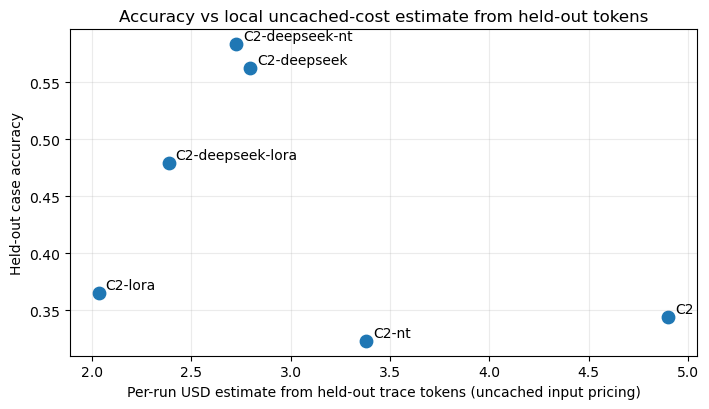

In [43]:
def expected_heldout_case_count() -> int:
    return sum(len(cases) for cases in HOLDOUT_CASES.values())


def trace_token_manifest(trace_dir: Path) -> dict:
    manifest_path = trace_dir / "manifest.json"
    if not manifest_path.exists():
        return {}
    return json.loads(manifest_path.read_text(encoding="utf-8"))


def trace_token_coverage_table(summary_path: Path) -> pd.DataFrame:
    session_to_system = {
        root.name: system
        for system, roots in session_roots_by_system.items()
        for root in roots
    }
    expected_cases = expected_heldout_case_count()
    if summary_path.exists():
        raw = pd.read_csv(summary_path)
        if "session_id" not in raw.columns:
            raw = pd.DataFrame()
    else:
        raw = pd.DataFrame()

    rows = []
    for session_id, system in sorted(session_to_system.items()):
        if raw.empty:
            rows.append(
                {
                    "system": system,
                    "session_id": session_id,
                    "status": "missing",
                    "case_count": 0,
                    "observation_count": 0,
                    "total_tokens": 0,
                    "models": "",
                }
            )
            continue
        session_rows = raw[raw["session_id"].astype(str) == str(session_id)]
        if session_rows.empty:
            rows.append(
                {
                    "system": system,
                    "session_id": session_id,
                    "status": "missing",
                    "case_count": 0,
                    "observation_count": 0,
                    "total_tokens": 0,
                    "models": "",
                }
            )
            continue
        case_count = int(session_rows["case_count"].max())
        total_tokens = int(session_rows["total_tokens"].sum())
        if total_tokens <= 0:
            status = "no_usage"
        elif case_count != expected_cases:
            status = "case_count_mismatch"
        else:
            status = "ok"
        rows.append(
            {
                "system": system,
                "session_id": session_id,
                "status": status,
                "case_count": case_count,
                "observation_count": int(session_rows["observation_count"].sum()),
                "total_tokens": total_tokens,
                "models": ", ".join(sorted(session_rows["model"].astype(str).unique())),
            }
        )
    out = pd.DataFrame(rows)
    out["system"] = pd.Categorical(out["system"], categories=EXPECTED_SYSTEMS, ordered=True)
    return out.sort_values(["system", "session_id"]).reset_index(drop=True)


def load_heldout_trace_tokens(summary_path: Path) -> pd.DataFrame:
    raw = pd.read_csv(summary_path)
    required = {
        "system",
        "session_id",
        "split",
        "role",
        "model",
        "input_uncached_tokens",
        "input_cached_tokens",
        "output_total_tokens",
        "total_tokens",
    }
    missing = sorted(required - set(raw.columns))
    if missing:
        raise ValueError(f"Trace token summary is missing columns: {missing}")
    heldout = raw[raw["split"] == "hold_out"].copy()
    heldout = heldout[heldout["system"].isin(EXPECTED_SYSTEMS)].copy()
    runs_by_system = per_case.groupby("system")["run"].nunique().to_dict()
    heldout["runs"] = heldout["system"].map(runs_by_system).astype(int)
    heldout["session_key"] = heldout["session_id"].astype(str)
    heldout["input_uncached"] = heldout["input_uncached_tokens"]
    heldout["input_cached"] = heldout["input_cached_tokens"]
    heldout["output"] = heldout["output_total_tokens"]
    heldout["total"] = heldout["total_tokens"]
    heldout["input_total"] = heldout["input_uncached"] + heldout["input_cached"]
    heldout["cache_hit_rate"] = np.where(
        heldout["input_total"] > 0,
        heldout["input_cached"] / heldout["input_total"],
        np.nan,
    )
    return heldout[
        [
            "system",
            "session_key",
            "experiment_name",
            "runs",
            "role",
            "model",
            "input_uncached",
            "input_cached",
            "output",
            "total",
            "case_count",
            "observation_count",
            "cache_hit_rate",
        ]
    ].reset_index(drop=True)


trace_manifest = trace_token_manifest(TRACE_TOKEN_DIR)
if trace_manifest:
    print(
        "Trace-token export: "
        f"{trace_manifest.get('counts', {}).get('token_rows', 'unknown')} token rows; "
        f"raw observations: {trace_manifest.get('raw_observations_jsonl', 'not recorded')}"
    )

trace_token_coverage = trace_token_coverage_table(HELD_OUT_TOKEN_SUMMARY_CSV)
display(trace_token_coverage)

lf = pd.DataFrame()
cost_ready = False
coverage_gaps = trace_token_coverage[trace_token_coverage["status"] != "ok"]
if not HELD_OUT_TOKEN_SUMMARY_CSV.exists():
    warnings.warn(
        f"Held-out trace token summary not found at {HELD_OUT_TOKEN_SUMMARY_CSV}; "
        "run scripts/export_langfuse_trace_tokens.py first."
    )
elif not coverage_gaps.empty:
    warnings.warn("Held-out trace-token coverage is incomplete; skipping token/cost plots.")
else:
    lf = load_heldout_trace_tokens(HELD_OUT_TOKEN_SUMMARY_CSV)
    missing_usage = sorted(set(EXPECTED_SYSTEMS) - set(lf["system"].unique()))
    if missing_usage:
        warnings.warn(f"Held-out trace tokens are missing for {missing_usage}; skipping token/cost plots.")
    elif lf.empty:
        warnings.warn("Held-out trace token summary had no rows for the scoped systems; skipping token/cost plots.")
    else:
        cost_ready = True

if cost_ready:
    token_summary = al.system_token_summary(lf).set_index("system").reindex(EXPECTED_SYSTEMS).reset_index()
    estimated_cost_summary = al.cost_dollars(lf).set_index("system").reindex(EXPECTED_SYSTEMS).reset_index()
    estimated_cost_summary = estimated_cost_summary[
        [
            "system",
            "runs",
            "total_usd_uncached",
            "per_run_usd_uncached",
            "total_usd_as_billed",
            "per_run_usd_as_billed",
        ]
    ]
    display(token_summary)

    cost_index = estimated_cost_summary.set_index("system")
    cost_pairs = [
        ("C2-lora", "C2-nt", "Qwen-side LoRA vs thinking-off"),
        ("C2-lora", "C2", "Qwen-side LoRA vs thinking"),
        ("C2-deepseek-lora", "C2-deepseek-nt", "DeepSeek-side LoRA vs thinking-off"),
        ("C2-deepseek-lora", "C2-deepseek", "DeepSeek-side LoRA vs thinking"),
    ]
    cost_comparison_rows = []
    for lhs, rhs, label in cost_pairs:
        lhs_uncached = cost_index.loc[lhs, "per_run_usd_uncached"]
        rhs_uncached = cost_index.loc[rhs, "per_run_usd_uncached"]
        lhs_billed = cost_index.loc[lhs, "per_run_usd_as_billed"]
        rhs_billed = cost_index.loc[rhs, "per_run_usd_as_billed"]
        cost_comparison_rows.append(
            {
                "comparison": label,
                "lhs": lhs,
                "rhs": rhs,
                "lhs_uncached_usd_per_run": lhs_uncached,
                "rhs_uncached_usd_per_run": rhs_uncached,
                "uncached_delta_pct": lhs_uncached / rhs_uncached - 1,
                "lhs_as_billed_usd_per_run": lhs_billed,
                "rhs_as_billed_usd_per_run": rhs_billed,
                "as_billed_delta_pct_secondary": lhs_billed / rhs_billed - 1,
            }
        )
    cost_comparison = pd.DataFrame(cost_comparison_rows)
    cost_comparison_display = cost_comparison.copy()
    money_cols = [
        "lhs_uncached_usd_per_run",
        "rhs_uncached_usd_per_run",
        "lhs_as_billed_usd_per_run",
        "rhs_as_billed_usd_per_run",
    ]
    for column in money_cols:
        cost_comparison_display[column] = cost_comparison_display[column].map(lambda value: f"${value:.4f}")
    for column in ["uncached_delta_pct", "as_billed_delta_pct_secondary"]:
        cost_comparison_display[column] = cost_comparison_display[column].map(lambda value: f"{100 * value:+.1f}%")
    print(
        "Primary dollar comparisons use held-out trace tokens with uncached-input pricing; "
        "as-billed deltas are secondary cache-sensitive context."
    )
    display(cost_comparison_display)
    display(estimated_cost_summary)

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.scatter(estimated_cost_summary["per_run_usd_uncached"], summary["case_acc_mean"], s=80)
    for _, row in estimated_cost_summary.iterrows():
        acc = summary_index.loc[row["system"], "case_acc_mean"]
        ax.annotate(row["system"], (row["per_run_usd_uncached"], acc), xytext=(5, 3), textcoords="offset points")
    ax.set_xlabel("Per-run USD estimate from held-out trace tokens (uncached input pricing)")
    ax.set_ylabel("Held-out case accuracy")
    ax.set_title("Accuracy vs local uncached-cost estimate from held-out tokens")
    ax.grid(alpha=0.25)
    fig.tight_layout()
else:
    print("Token/cost plots skipped; accuracy tables above are unaffected.")


## Optional CSV export


In [10]:
if EXPORT_CSV:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    provenance.to_csv(EXPORT_DIR / "provenance.csv", index=False)
    summary.to_csv(EXPORT_DIR / "accuracy_summary.csv", index=False)
    per_run.to_csv(EXPORT_DIR / "per_run_breakdown.csv", index=False)
    level_summary.to_csv(EXPORT_DIR / "level_breakdown.csv", index=False)
    pairwise_deltas.to_csv(EXPORT_DIR / "pairwise_deltas.csv", index=False)
    l2_ds_agreement.to_csv(EXPORT_DIR / "l2_deepseek_lora_agreement.csv", index=False)
    if "token_summary" in globals():
        token_summary.to_csv(EXPORT_DIR / "held_out_token_summary.csv", index=False)
    if "estimated_cost_summary" in globals():
        estimated_cost_summary.to_csv(EXPORT_DIR / "estimated_cost_summary.csv", index=False)
    if "cost_comparison" in globals():
        cost_comparison.to_csv(EXPORT_DIR / "cost_comparison.csv", index=False)
    print(f"Wrote CSV exports to {EXPORT_DIR}")
else:
    print(f"CSV export disabled. Set EXPORT_CSV = True to write task-specific outputs under {EXPORT_DIR}.")


CSV export disabled. Set EXPORT_CSV = True to write task-specific outputs under /Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/deepplanning/held_out_lora_analysis.
